<a href="https://colab.research.google.com/github/mlnjsh/timesage/blob/master/notebooks/timesage_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TimeSage Complete Demo - Airline Passengers Dataset

> **The Wise Time Series Library** - Beautiful EDA, All Models, Plain-English Interpretation

This notebook demonstrates **every feature** of timesage-ts using the classic airline passengers dataset.

- Install: `pip install timesage-ts[full]`
- Docs: [GitHub](https://github.com/mlnjsh/timesage)
- PyPI: [timesage-ts](https://pypi.org/project/timesage-ts/)

## Installation

In [ ]:
!pip install timesage-ts[full] -q

## Import & Setup

In [52]:
import timesage as ts
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

ts.hello()

╭────────────────────────────────────────────── Welcome to TimeSage ──────────────────────────────────────────────╮
│ TimeSage v0.2.2                                                                                                 │
│ The Wise Time Series Library                                                                                    │
│                                                                                                                 │
│ Quick Start:                                                                                                    │
│   import timesage as ts                                                                                         │
│   data = ts.load_airline()                                                                                      │
│   series = ts.TimeSeries(data, target='passengers')                                                             │
│   series.eda()                                                                                                  │
│   result = series.forecast(horizon=30)                                                                          │
│   result.interpret()                                                                                            │
│                                                                                                                 │
│ Built-in Datasets: airline, sunspots, energy, synthetic_trend, synthetic_seasonal                               │
│ Models: ARIMA, ETS, Theta, RandomForest, XGBoost, LightGBM, Auto                                                │
│ Author: Milan Amrut Joshi                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Load Airline Passengers Dataset

Classic Box-Jenkins dataset: monthly totals of international airline passengers (1949-1960), 144 observations.

In [53]:
data = ts.load_airline()
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
data.head(10)

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


,passengers
time,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


## Create TimeSeries Object

In [54]:
series = ts.TimeSeries(data, name="Airline Passengers")
print(series)

TimeSeries(name='Airline Passengers', length=144, freq='monthly', range=[1949-01-01 -> 1960-12-01])


## Basic Description

In [55]:
series.describe()

,passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000
skewness,0.583160
kurtosis,-0.364942


## Plot Raw Series

In [ ]:
series.plot()
plt.show()

## Trend & Outlier Detection

In [ ]:
series.plot(show_trend=True, show_outliers=True)
plt.show()

## Theme Gallery

TimeSage ships with 3 themes: **sage** (default), **dark**, **minimal**.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, theme_name in zip(axes, ["sage", "dark", "minimal"]):
    ts.set_theme(theme_name)
    series.plot(ax=ax)
    ax.set_title(f"Theme: {theme_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
ts.set_theme("sage")

## Stationarity Testing

Augmented Dickey-Fuller (ADF) and KPSS tests.

In [59]:
series.test_stationarity()

                     Stationarity Tests                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Test                  ┃ Statistic ┃ P-value ┃ Stationary? ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━┩
│ ADF (H0: non-stat)    │    0.8154 │  0.9919 │     No      │
│ KPSS (H0: stationary) │    1.6513 │  0.0100 │     No      │
└───────────────────────┴───────────┴─────────┴─────────────┘

NON-STATIONARY -- Both tests agree the series has a unit root.

{'adf': {'statistic': np.float64(0.8153688792060498),
  'p_value': np.float64(0.991880243437641),
  'stationary': np.False_},
 'kpss': {'statistic': np.float64(1.6513122354165206),
  'p_value': np.float64(0.01),
  'stationary': np.False_},
 'conclusion': 'NON-STATIONARY -- Both tests agree the series has a unit root.'}

## Seasonality Detection

ACF peak analysis for seasonal patterns.

In [60]:
series.detect_seasonality()

Seasonality detected! Primary period: 12

{'seasonal': True,
 'period': 12,
 'peaks': [(12, np.float64(0.7603950422625557)),
  (24, np.float64(0.532189830465802)),
  (36, np.float64(0.33702359902053575))],
 'acf_values': array([1.        , 0.94804734, 0.87557484, 0.80668116, 0.75262542,
        0.71376997, 0.6817336 , 0.66290439, 0.65561048, 0.67094833,
        0.70271992, 0.74324019, 0.76039504, 0.71266087, 0.64634228,
        0.58592342, 0.53795519, 0.49974753, 0.46873401, 0.44987066,
        0.4416288 , 0.45722376, 0.48248203, 0.51712699, 0.53218983,
        0.49397569, 0.43772134, 0.3876029 , 0.34802503, 0.31498388,
        0.28849682, 0.27080187, 0.26429011, 0.27679934, 0.2985215 ,
        0.32558712, 0.3370236 , 0.30333486, 0.25397708, 0.21065534,
        0.17217092, 0.13840041, 0.11140324, 0.09098453, 0.08217177,
        0.08877222, 0.10386958, 0.12393082, 0.13263456])}

## ACF & PACF

In [ ]:
series.plot_acf(lags=40)
plt.show()

# Interpret ACF/PACF patterns
series.interpret_acf(lags=40)

## Time Series Decomposition

Trend + Seasonal + Residual components.

In [ ]:
series.plot_decomposition(model="additive", period=12)
plt.show()

## Full EDA

One command for everything: description, stationarity, seasonality, and plots.

                     Stationarity Tests                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Test                  ┃ Statistic ┃ P-value ┃ Stationary? ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━┩
│ ADF (H0: non-stat)    │    0.8154 │  0.9919 │     No      │
│ KPSS (H0: stationary) │    1.6513 │  0.0100 │     No      │
└───────────────────────┴───────────┴─────────┴─────────────┘

NON-STATIONARY -- Both tests agree the series has a unit root.

Seasonality detected! Primary period: 12

    Summary Statistics    
┏━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric      ┃    Value ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ count       │ 144.0000 │
│ mean        │ 280.2986 │
│ std         │ 119.9663 │
│ min         │ 104.0000 │
│ 25%         │ 180.0000 │
│ 50%         │ 265.5000 │
│ 75%         │ 360.5000 │
│ max         │ 622.0000 │
│ skewness    │   0.5832 │
│ kurtosis    │  -0.3649 │
│ missing     │   0.0000 │
│ missing_pct │   0.0000 │
│ cv          │   0.4280 │
└─────────────┴──────────┘

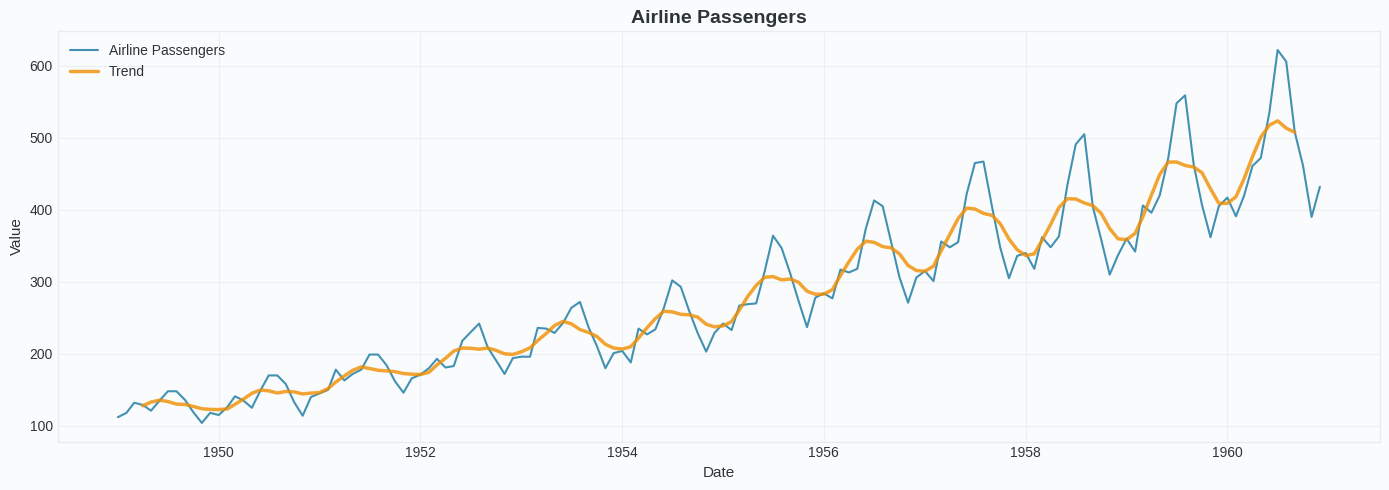

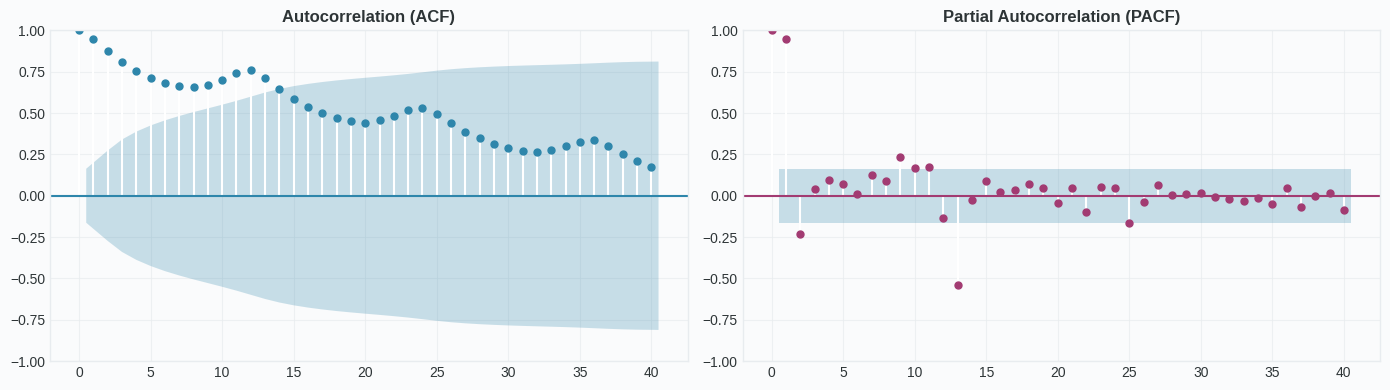

{'statistics': count          144.000000
 mean           280.298611
 std            119.966317
 min            104.000000
 25%            180.000000
 50%            265.500000
 75%            360.500000
 max            622.000000
 skewness         0.583160
 kurtosis        -0.364942
 missing          0.000000
 missing_pct      0.000000
 cv               0.427995
 Name: passengers, dtype: float64,
 'stationarity': {'adf': {'statistic': np.float64(0.8153688792060498),
   'p_value': np.float64(0.991880243437641),
   'stationary': np.False_},
  'kpss': {'statistic': np.float64(1.6513122354165206),
   'p_value': np.float64(0.01),
   'stationary': np.False_},
  'conclusion': 'NON-STATIONARY -- Both tests agree the series has a unit root.'},
 'seasonality': {'seasonal': True,
  'period': 12,
  'peaks': [(12, np.float64(0.7603950422625557)),
   (24, np.float64(0.532189830465802)),
   (36, np.float64(0.33702359902053575))],
  'acf_values': array([1.        , 0.94804734, 0.87557484, 0.80668116, 

In [63]:
series.eda(show_plots=True)

---
## Feature Engineering

Create ML features: lags, rolling stats, EWM, temporal features.

In [64]:
features_df = series.create_features(
    lags=[1, 2, 3, 6, 12, 24],
    windows=[3, 6, 12],
    temporal=True
)
print(f"Features shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")
features_df.head()

Features shape: (120, 34)
Columns: ['passengers', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'roll_mean_3', 'roll_std_3', 'roll_min_3', 'roll_max_3', 'roll_mean_6', 'roll_std_6', 'roll_min_6', 'roll_max_6', 'roll_mean_12', 'roll_std_12', 'roll_min_12', 'roll_max_12', 'ewm_7', 'ewm_14', 'ewm_30', 'diff_1', 'diff_7', 'pct_change_1', 'pct_change_7', 'day_of_week', 'day_of_month', 'month', 'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end']


,passengers,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,roll_mean_3,roll_std_3,roll_min_3,...,pct_change_1,pct_change_7,day_of_week,day_of_month,month,quarter,week_of_year,is_weekend,is_month_start,is_month_end
time,,,,,,,,,,,,,,,,,,,,,
1951-01-01,145,140.0,114.0,133.0,170.0,115.0,112.0,133.000000,16.643317,114.0,...,0.035714,-0.026846,0,1,1,1,1,0,1,0
1951-02-01,150,145.0,140.0,114.0,170.0,126.0,118.0,145.000000,5.000000,140.0,...,0.034483,-0.117647,3,1,2,1,5,0,1,0
1951-03-01,178,150.0,145.0,140.0,158.0,141.0,132.0,157.666667,17.785762,145.0,...,0.186667,0.047059,3,1,3,1,9,0,1,0
1951-04-01,163,178.0,150.0,145.0,133.0,135.0,129.0,163.666667,14.011900,150.0,...,-0.084270,0.031646,6,1,4,2,13,1,1,0
1951-05-01,172,163.0,178.0,150.0,114.0,125.0,121.0,171.000000,7.549834,163.0,...,0.055215,0.293233,1,1,5,2,18,0,1,0


### Feature Pipeline Direct Use

In [65]:
from timesage.features import FeaturePipeline

pipeline = FeaturePipeline(target="passengers",
    lags=[1, 2, 3, 6, 12],
    windows=[3, 6, 12],
    temporal=True
)
feat_df = pipeline.transform(series.dataframe)
print(f"Total features: {feat_df.shape[1]}")
feat_df.dropna().head()

Total features: 33


,passengers,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_std_3,roll_min_3,roll_max_3,...,pct_change_1,pct_change_7,day_of_week,day_of_month,month,quarter,week_of_year,is_weekend,is_month_start,is_month_end
time,,,,,,,,,,,,,,,,,,,,,
1950-01-01,115,118.0,104.0,119.0,148.0,112.0,112.333333,7.371115,104.0,118.0,...,-0.025424,-0.148148,6,1,1,1,52,1,1,0
1950-02-01,126,115.0,118.0,104.0,148.0,118.0,119.666667,5.686241,115.0,126.0,...,0.095652,-0.148649,2,1,2,1,5,0,1,0
1950-03-01,141,126.0,115.0,118.0,136.0,132.0,127.333333,13.051181,115.0,141.0,...,0.119048,-0.047297,2,1,3,1,9,0,1,0
1950-04-01,135,141.0,126.0,115.0,119.0,129.0,134.000000,7.549834,126.0,141.0,...,-0.042553,-0.007353,5,1,4,2,13,1,1,0
1950-05-01,125,135.0,141.0,126.0,104.0,121.0,133.666667,8.082904,125.0,141.0,...,-0.074074,0.050420,0,1,5,2,18,0,1,0


---
## Statistical Models

### ARIMA
Automatically selects best (p,d,q) via AIC grid search.

In [66]:
result_arima = series.forecast(horizon=12, model="arima")
result_arima.summary()

╭───────────────────────────────────────── ARIMA Forecast Interpretation ─────────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Moderate] The model achieves moderate accuracy with an average error of 13.5%. For every 100 units of       │
│  actual value, the prediction is typically off by about 13.5 units.                                             │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has CONSISTENT errors (RMSE/MAE ratio = 1.33).                                                     │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 2.95). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +2.2% over the prediction horizon. Peak: 571.31.                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,MAE,RMSE,MSE,MedAE,MAPE,R2,MASE
ARIMA,62.063473,82.635764,6828.669508,49.118382,13.540017,-0.118631,2.946787


In [ ]:
result_arima.plot()
plt.show()

### ETS (Holt-Winters)
Exponential smoothing with level, trend, and seasonality.

In [68]:
result_ets = series.forecast(horizon=12, model="ets")
result_ets.summary()

╭────────────────────────────────────────── ETS Forecast Interpretation ──────────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Poor] The model achieves poor accuracy with an average error of 24.6%. For every 100 units of actual        │
│  value, the prediction is typically off by about 24.6 units.                                                    │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has very CONSISTENT errors (RMSE/MAE ratio = 1.12).                                                │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 4.64). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +3.6% over the prediction horizon. Peak: 449.29.                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,MAE,RMSE,MSE,MedAE,MAPE,R2,MASE
ETS,97.771635,109.190179,11922.495208,102.186712,24.574583,-0.95307,4.642218


In [ ]:
result_ets.plot()
plt.show()

### Theta Method

In [70]:
result_theta = series.forecast(horizon=12, model="theta")
result_theta.summary()

╭───────────────────────────────────────── Theta Forecast Interpretation ─────────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Good] The model achieves good accuracy with an average error of 7.0%. For every 100 units of actual value,  │
│  the prediction is typically off by about 7.0 units.                                                            │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has very CONSISTENT errors (RMSE/MAE ratio = 1.19).                                                │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 1.53). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +1.7% over the prediction horizon. Peak: 602.74.                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,MAE,RMSE,MSE,MedAE,MAPE,R2,MASE
Theta,32.161519,38.341484,1470.069396,28.049275,6.995898,0.759182,1.527036


In [ ]:
result_theta.plot()
plt.show()

---
## Machine Learning Models

### Random Forest

In [72]:
result_rf = series.forecast(horizon=12, model="rf")
result_rf.summary()

╭───────────────────────────────────── RandomForest Forecast Interpretation ──────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Moderate] The model achieves moderate accuracy with an average error of 15.3%. For every 100 units of       │
│  actual value, the prediction is typically off by about 15.3 units.                                             │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has CONSISTENT errors (RMSE/MAE ratio = 1.30).                                                     │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 3.38). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Key Drivers:                                                                                                 │
│    Top predictive features: 'lag_1' (67.5%), 'roll_mean_14' (21.3%), 'roll_mean_7' (2.7%), 'lag_3' (2.1%),      │
│  'roll_std_7' (1.3%).                                                                                           │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +11.1% over the prediction horizon. Peak: 519.33.                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,MAE,RMSE,MSE,MedAE,MAPE,R2,MASE
RandomForest,71.226897,92.393413,8536.542752,62.2,15.266142,-0.398404,3.381868


In [ ]:
result_rf.plot()
plt.show()

### XGBoost

In [74]:
result_xgb = series.forecast(horizon=12, model="xgboost")
result_xgb.summary()

╭──────────────────────────────────────── XGBoost Forecast Interpretation ────────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Moderate] The model achieves moderate accuracy with an average error of 12.8%. For every 100 units of       │
│  actual value, the prediction is typically off by about 12.8 units.                                             │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has CONSISTENT errors (RMSE/MAE ratio = 1.30).                                                     │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 2.66). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Key Drivers:                                                                                                 │
│    Top predictive features: 'lag_1' (86.7%), 'roll_mean_14' (5.5%), 'month' (1.9%), 'lag_7' (1.3%),             │
│  'roll_mean_7' (1.1%).                                                                                          │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +23.2% over the prediction horizon. Peak: 580.07.                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,MAE,RMSE,MSE,MedAE,MAPE,R2,MASE
XGBoost,56.123982,72.746909,5292.112827,38.863678,12.830775,0.133079,2.664779


In [ ]:
result_xgb.plot()
plt.show()

### LightGBM

In [76]:
result_lgb = series.forecast(horizon=12, model="lightgbm")
result_lgb.summary()

╭─────────────────────────────────────── LightGBM Forecast Interpretation ────────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Moderate] The model achieves moderate accuracy with an average error of 14.9%. For every 100 units of       │
│  actual value, the prediction is typically off by about 14.9 units.                                             │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has CONSISTENT errors (RMSE/MAE ratio = 1.27).                                                     │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 3.43). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Key Drivers:                                                                                                 │
│    Top predictive features: 'month' (28.0%), 'lag_1' (18.8%), 'roll_mean_14' (11.1%), 'lag_7' (9.4%), 'lag_2'   │
│  (7.5%).                                                                                                        │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +7.7% over the prediction horizon. Peak: 526.35.                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,MAE,RMSE,MSE,MedAE,MAPE,R2,MASE
LightGBM,72.176275,91.749989,8418.060467,54.724394,14.946429,-0.378995,3.426945


In [ ]:
result_lgb.plot()
plt.show()

---
## AutoML - Automatic Model Selection

TimeSage trains ARIMA, ETS, Theta, RF on validation, picks the winner by lowest MAPE.

In [78]:
result_auto = series.forecast(horizon=12, model="auto")
result_auto.summary()

╭───────────────────────────────────────── Auto Forecast Interpretation ──────────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Good] The model achieves good accuracy with an average error of 7.0%. For every 100 units of actual value,  │
│  the prediction is typically off by about 7.0 units.                                                            │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has very CONSISTENT errors (RMSE/MAE ratio = 1.19).                                                │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 1.53). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +1.7% over the prediction horizon. Peak: 602.74.                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

,MAE,RMSE,MSE,MedAE,MAPE,R2,MASE
Auto,32.161519,38.341484,1470.069396,28.049275,6.995898,0.759182,1.527036


In [ ]:
result_auto.plot()
plt.show()

---
## Plain-English Interpretation

Understand your forecast without a statistics degree.

In [80]:
result_auto.interpret()

╭───────────────────────────────────────── Auto Forecast Interpretation ──────────────────────────────────────────╮
│                                                                                                                 │
│    Overall Accuracy:                                                                                            │
│    [Good] The model achieves good accuracy with an average error of 7.0%. For every 100 units of actual value,  │
│  the prediction is typically off by about 7.0 units.                                                            │
│                                                                                                                 │
│    Error Pattern:                                                                                               │
│    The model has very CONSISTENT errors (RMSE/MAE ratio = 1.19).                                                │
│                                                                                                                 │
│    Benchmark:                                                                                                   │
│    The model UNDERPERFORMS a naive forecast (MASE = 1.53). A simple repeat-last-value strategy would be         │
│  better.                                                                                                        │
│                                                                                                                 │
│    Forecast Direction:                                                                                          │
│    The forecast shows an UPWARD trend of +1.7% over the prediction horizon. Peak: 602.74.                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Detailed Interpretation Breakdown

In [82]:
from timesage.interpret.explainer import explain_forecast

explanation = explain_forecast(result_auto)
for key, value in explanation.items():
    sep = "=" * 60
    print(f"{sep}")
    print(f"{key.upper().replace(chr(95), chr(32))}")
    print(f"{sep}")
    print(f"{value}")

╭────────────────────────────────╮
│ Auto — Detailed Interpretation │
╰────────────────────────────────╯

OVERALL ACCURACY

[Very Good] The Auto model achieves very good accuracy with an average error of 7.0%. In practical terms, for 
every 100 units of actual value, the model's prediction is typically off by about 7.0 units.

ERROR PATTERN

The model has CONSISTENT errors (RMSE/MAE ratio = 1.19). Errors are relatively uniform — the model doesn't have 
blind spots. Average absolute error: 32.16, root mean square error: 38.34.

...

PREDICTABILITY

The model explains 75.9% of the variance — moderate. About half the variation remains unexplained. Adding more 
features or trying different models could help.

FORECAST DIRECTION

The forecast is relatively FLAT over the prediction horizon, changing by only +1.7%. Expected range: 397.94 to 
602.74.

OVERALL ACCURACY
[Very Good] The Auto model achieves very good accuracy with an average error of 7.0%. In practical terms, for every 100 units of actual value, the model's prediction is typically off by about 7.0 units.
ERROR PATTERN
The model has CONSISTENT errors (RMSE/MAE ratio = 1.19). Errors are relatively uniform — the model doesn't have blind spots. Average absolute error: 32.16, root mean square error: 38.34.
BENCHMARK
The model UNDERPERFORMS a naive forecast (MASE = 1.53). A simpler approach (e.g., using yesterday's value) would be more accurate. Action items: Check for data issues, try different features, or consider if this series is inherently unpredictable.
PREDICTABILITY
The model explains 75.9% of the variance — moderate. About half the variation remains unexplained. Adding more features or trying different models could help.
FORECAST DIRECTION
The forecast is relatively FLAT over the prediction horizon, changing by only +1.7%. Expected range: 397.94 to 602.74.


## Residual Diagnostics

Bias, normality, autocorrelation, heteroscedasticity checks.

In [83]:
from timesage.interpret.diagnostics import diagnose_residuals

diagnosis = diagnose_residuals(result_auto.residuals)
for test_name, result in diagnosis.items():
    print(f"{test_name}:")
    if isinstance(result, dict):
        for k, v in result.items():
            print(f"{k}: {v}")
    else:
        print(f"{result}")

AttributeError: 'NoneType' object has no attribute 'dropna'

## Model Comparison - All Models Side by Side

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
models = ["arima", "ets", "theta", "rf", "xgboost", "lightgbm"]
results = {}
for ax, model_name in zip(axes.flat, models):
    try:
        result = series.forecast(horizon=12, model=model_name, verbose=False)
        results[model_name] = result
        from timesage.plot.timeplots import plot_forecast
        plot_forecast(result, ax=ax)
        ax.set_title(f"{model_name.upper()} (MAPE: {result.mape:.1f}%)", fontsize=12, fontweight="bold")
    except Exception as e:
        ax.set_title(f"{model_name.upper()} - Error")
        ax.text(0.5, 0.5, str(e)[:80], ha="center", va="center", fontsize=9)
plt.suptitle("Model Comparison - Airline Passengers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Metrics Comparison Table

In [ ]:
metrics_data = []
for name, res in results.items():
    metrics_data.append({
        "Model": name.upper(),
        "MAE": round(res.mae, 2),
        "RMSE": round(res.rmse, 2),
        "MAPE (%)": round(res.mape, 2),
        "R2": round(res.r2, 4),
        "MASE": round(res.mase, 4) if res.mase else None
    })
comparison_df = pd.DataFrame(metrics_data).sort_values("MAPE (%)")
print("Best model by MAPE:", comparison_df.iloc[0]["Model"])
comparison_df

## Custom Forecast Parameters

In [ ]:
result_custom = series.forecast(
    horizon=24,
    model="auto",
    test_size=0.2,
    confidence=0.95
)
result_custom.summary()

In [ ]:
result_custom.plot()
plt.show()

## Feature Importance (ML Models)

In [ ]:
result_rf2 = series.forecast(horizon=12, model="rf")
if hasattr(result_rf2, "feature_importance") and result_rf2.feature_importance:
    print("Random Forest - Top Features:
")
    sorted_feats = sorted(result_rf2.feature_importance.items(), key=lambda x: x[1], reverse=True)
    for i, (name, score) in enumerate(sorted_feats[:15], 1):
        bar = chr(9608) * int(score * 50)
        print(f"  {i:2d}. {name:20s} {score:.4f} {bar}")
else:
    print("Feature importance not available")

## Other Built-in Datasets

In [ ]:
sunspots = ts.load_sunspots()
print(f"Sunspots: {sunspots.shape[0]} observations")
trend_data = ts.load_synthetic_trend()
seasonal_data = ts.load_synthetic_seasonal()
print(f"Synthetic Trend: {trend_data.shape[0]} observations")
print(f"Synthetic Seasonal: {seasonal_data.shape[0]} observations")

sun_series = ts.TimeSeries(sunspots, name="Sunspots")
sun_series.plot()
plt.show()

## Color Palette

In [ ]:
from timesage.plot.theme import COLORS, PALETTE
print("TimeSage Color Palette:
")
for name, hex_code in COLORS.items():
    print(f"  {name:12s}  {hex_code}")
print(f"
Full palette: {PALETTE}")

---
## Summary

| Feature | Command |
|---|---|
| Load data | `ts.load_airline()` |
| TimeSeries | `ts.TimeSeries(data)` |
| Describe | `series.describe()` |
| Plot | `series.plot()` |
| Stationarity | `series.test_stationarity()` |
| Seasonality | `series.detect_seasonality()` |
| ACF/PACF | `series.plot_acf()` |
| Decompose | `series.decompose()` |
| Full EDA | `series.eda()` |
| Features | `series.create_features()` |
| ARIMA | `series.forecast(model="arima")` |
| ETS | `series.forecast(model="ets")` |
| Theta | `series.forecast(model="theta")` |
| Random Forest | `series.forecast(model="rf")` |
| XGBoost | `series.forecast(model="xgboost")` |
| LightGBM | `series.forecast(model="lightgbm")` |
| AutoML | `series.forecast(model="auto")` |
| Interpret | `result.interpret()` |
| Diagnostics | `diagnose_residuals()` |
| Themes | `ts.set_theme("dark")` |

---
**Made with [TimeSage](https://github.com/mlnjsh/timesage) | pip install timesage-ts[full]**